In [1]:
# General Libraries
import sys
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import copy

# FNO Model Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product

print("numpy:", np.__version__)
print("torch:", torch.__version__)

# Compatibility aliases for loading pickles created with NumPy 2.x
import numpy.core
import numpy.core.numeric
import numpy.core.multiarray
import numpy.core.umath

sys.modules["numpy._core"] = numpy.core
sys.modules["numpy._core.numeric"] = numpy.core.numeric
sys.modules["numpy._core.multiarray"] = numpy.core.multiarray
sys.modules["numpy._core.umath"] = numpy.core.umath 

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

numpy: 1.26.4
torch: 2.2.1+cu121
device: cuda


In [2]:
# Set seed of notebook for reproducibility
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # More reproducible CUDA behavior
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(0)

In [3]:
bat_df = pd.read_pickle("data/bat_df.pkl")
print(bat_df.shape)

(124, 12)


In [4]:
# Splits from original paper
numBat1 = 41
numBat2 = 43
numBat3 = 40
numBat = numBat1 + numBat2 + numBat3

test_ind = np.hstack((np.arange(0, (numBat1 + numBat2), 2), 83))
train_ind = np.arange(1, (numBat1 + numBat2 - 1), 2)
secondary_test_ind = np.arange(numBat - numBat3, numBat)

train_df = bat_df.iloc[train_ind].reset_index(drop=True)
primary_test_df = bat_df.iloc[test_ind].reset_index(drop=True)
secondary_test_df = bat_df.iloc[secondary_test_ind].reset_index(drop=True)

print("train_df:", train_df.shape)
print("primary_test_df:", primary_test_df.shape)
print("secondary_test_df:", secondary_test_df.shape)

train_df: (41, 12)
primary_test_df: (43, 12)
secondary_test_df: (40, 12)


In [5]:
# Directly fix outlier QD: b1c18, cycle 40
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c18"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[39] = 0.5 * (QD[38] + QD[40])   # cycle_idx 39 = cycle 40
primary_test_df.at[idx, "QD"] = QD

# Directly fix outlier QD: b1c0, cycle 12
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c0"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[11] = 0.5 * (QD[10] + QD[12])   # cycle_idx 11 = cycle 12
primary_test_df.at[idx, "QD"] = QD

In [6]:
# Build FNO dataset using Qdlin_cycle_X - Qdlin_cycle_10 every 5 cycles from 20 to 100
def build_fno_arrays(df, split_name):
    X_list = []
    y_list = []
    battery_ids = []

    # For each battery
    for _, row in df.iterrows():

        battery_tensor = []

        # Get cycle 10 qdlin
        q_10 = np.asarray(row["cycles"]["9"]["Qdlin"], dtype=float).squeeze()

        # Get cycle qdlin changes for all cycles for current battery
        for cyc_idx in range(19, 100, 5):
            q_curr = np.asarray(row["cycles"][str(cyc_idx)]["Qdlin"], dtype=float).squeeze()
            dq = q_curr - q_10
            battery_tensor.append(dq)

        # Shape: [selected_cycles, voltage]
        battery_tensor = np.stack(battery_tensor, axis=0)

        # Add channel dimension: [selected_cycles, voltage, channels]
        battery_tensor = battery_tensor[..., None]

        X_list.append(battery_tensor)
        y_list.append(np.log10(row["cycle_life"]))
        battery_ids.append(row["battery_id"])

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.asarray(y_list, dtype=np.float32).reshape(-1, 1)

    print(split_name)
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y, battery_ids


X_train, y_train, train_ids = build_fno_arrays(train_df, "train")
X_primary, y_primary, primary_ids = build_fno_arrays(primary_test_df, "primary_test")
X_secondary, y_secondary, secondary_ids = build_fno_arrays(secondary_test_df, "secondary_test")

train
X shape: (41, 17, 1000, 1)
y shape: (41, 1)
primary_test
X shape: (43, 17, 1000, 1)
y shape: (43, 1)
secondary_test
X shape: (40, 17, 1000, 1)
y shape: (40, 1)


In [7]:
# Normalize inputs using only train set
X_mean = X_train.mean()
X_std = X_train.std()

X_train_n = (X_train - X_mean) / X_std
X_primary_n = (X_primary - X_mean) / X_std
X_secondary_n = (X_secondary - X_mean) / X_std

# Normalize targets using only train set
y_mean = y_train.mean()
y_std = y_train.std()

y_train_n = (y_train - y_mean) / y_std
y_primary_n = (y_primary - y_mean) / y_std
y_secondary_n = (y_secondary - y_mean) / y_std

# Convert datasets to tensors
X_train_t = torch.tensor(X_train_n, dtype=torch.float32)
X_primary_t = torch.tensor(X_primary_n, dtype=torch.float32)
X_secondary_t = torch.tensor(X_secondary_n, dtype=torch.float32)

y_train_t = torch.tensor(y_train_n, dtype=torch.float32).view(-1, 1)
y_primary_t = torch.tensor(y_primary_n, dtype=torch.float32).view(-1, 1)
y_secondary_t = torch.tensor(y_secondary_n, dtype=torch.float32).view(-1, 1)

In [8]:
# FNO Model
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_cycle, modes_voltage):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_cycle = modes_cycle
        self.modes_voltage = modes_voltage

        scale = 1 / (in_channels * out_channels)

        self.weights = nn.Parameter(
            scale * torch.randn(
                in_channels,
                out_channels,
                modes_cycle,
                modes_voltage,
                dtype=torch.cfloat
            )
        )

    def compl_mul2d(self, input, weights):
        # input:   [batch, in_channels, x, y]
        # weights: [in_channels, out_channels, x, y]
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]

        # Fourier transform
        x_ft = torch.fft.rfft2(x)

        # Output in Fourier domain
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        # Keep only low-frequency modes
        out_ft[:, :, :self.modes_cycle, :self.modes_voltage] = self.compl_mul2d(
            x_ft[:, :, :self.modes_cycle, :self.modes_voltage],
            self.weights
        )

        # Back to physical domain
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

        return x


class FNO2dBattery(nn.Module):
    def __init__(self, in_channels=1, width=24, modes_cycle=12, modes_voltage=32):
        super().__init__()

        self.width = width

        # Lift input channel to width channels
        self.fc0 = nn.Linear(in_channels + 2, width)

        self.conv0 = SpectralConv2d(width, width, modes_cycle, modes_voltage)
        self.conv1 = SpectralConv2d(width, width, modes_cycle, modes_voltage)
        self.conv2 = SpectralConv2d(width, width, modes_cycle, modes_voltage)

        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)

        self.regressor = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1)
        )

    def get_grid(self, batchsize, size_cycle, size_voltage, device):
        cycle_grid = torch.linspace(0, 1, size_cycle, device=device)
        voltage_grid = torch.linspace(0, 1, size_voltage, device=device)

        cycle_grid = cycle_grid.reshape(1, size_cycle, 1, 1).repeat(batchsize, 1, size_voltage, 1)
        voltage_grid = voltage_grid.reshape(1, 1, size_voltage, 1).repeat(batchsize, size_cycle, 1, 1)

        return torch.cat([cycle_grid, voltage_grid], dim=-1)

    def forward(self, x):
        # x shape: [batch, cycles, voltage, channels]

        batchsize, size_cycle, size_voltage, channels = x.shape

        grid = self.get_grid(batchsize, size_cycle, size_voltage, x.device)

        # Add coordinate grid
        x = torch.cat([x, grid], dim=-1)

        # Lift
        x = self.fc0(x)

        # [batch, cycles, voltage, width] -> [batch, width, cycles, voltage]
        x = x.permute(0, 3, 1, 2)

        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))

        # Global average pooling over cycle and voltage dimensions
        x = x.mean(dim=(-2, -1))

        # Predict normalized log10(cycle_life)
        out = self.regressor(x)

        return out

In [9]:
# Model training function

def train_fno_model(model, train_loader, val_loader, lr, weight_decay, epochs, suppress_print=False):
    # Use MSELoss and AdamW
    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = np.inf
    best_state = None

    train_losses = []
    val_losses = []

    model.to(device)

    # Train for number of epochs
    for epoch in range(epochs):

        # Training
        model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            preds = model(X_batch)

            loss = torch.sqrt(criterion(preds, y_batch))

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # Validation
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(X_batch)

                loss = torch.sqrt(criterion(preds, y_batch))

                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        if not suppress_print and epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    model.load_state_dict(best_state)

    return model, train_losses, val_losses


# K-fold Cross-validation (K=4 like the paper)
def cross_validate_fno_model(config, X_tensor, y_array, n_splits):

    # Create folds
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_losses = []

    # Loop through fold splits
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_tensor)):

        print(f"\nFold {fold + 1}/{n_splits}")

        X_train_fold = X_tensor[train_idx]
        X_val_fold = X_tensor[val_idx]

        y_train_fold = torch.tensor(y_array[train_idx], dtype=torch.float32).view(-1, 1)
        y_val_fold = torch.tensor(y_array[val_idx], dtype=torch.float32).view(-1, 1)

        train_dataset = TensorDataset(X_train_fold, y_train_fold)
        val_dataset = TensorDataset(X_val_fold, y_val_fold)

        # Create dataloaders for model input
        # Set generator seed for reproducibility
        g = torch.Generator()
        g.manual_seed(0)

        train_loader = DataLoader(
            train_dataset,
            batch_size=config["batch_size"],
            shuffle=True,
            generator=g
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=config["batch_size"],
            shuffle=False,
            generator=g
        )

        # Create FNO model
        model = FNO2dBattery(
            in_channels=1,
            width=config["width"],
            modes_cycle=config["modes_cycle"],
            modes_voltage=config["modes_voltage"]
        )

        # Train FNO model
        model, train_losses, val_losses = train_fno_model(
            model,
            train_loader,
            val_loader,
            lr=config["lr"],
            weight_decay=config["weight_decay"],
            epochs=config["epochs"],
            suppress_print=False
        )

        best_fold_loss = min(val_losses)

        print(f"Best Fold Validation Loss: {best_fold_loss:.6f}")

        fold_losses.append(best_fold_loss)

    mean_cv_loss = np.mean(fold_losses)

    print("\nMean CV Loss:", mean_cv_loss)

    return mean_cv_loss

In [10]:
# FNO hyperparameter search
fno_search_space = [

    {
        "width": 24,
        "modes_cycle": 10,
        "modes_voltage": 32,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 16,
        "epochs": 300
    },

    {
        "width": 16,
        "modes_cycle": 6,
        "modes_voltage": 24,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 16,
        "epochs": 300
    },

    {
        "width": 30,
        "modes_cycle": 16,
        "modes_voltage": 40,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 16,
        "epochs": 300
    }
]


best_fno_config = None
best_fno_cv_loss = np.inf

for config in fno_search_space:

    print("\n================================================")
    print("Testing FNO Configuration:")
    print(config)

    cv_loss = cross_validate_fno_model(
        config=config,
        X_tensor=X_train_t,
        y_array=y_train_n,
        n_splits=4
    )

    if cv_loss < best_fno_cv_loss:
        best_fno_cv_loss = cv_loss
        best_fno_config = config


print("\n================================================")
print("BEST FNO CONFIGURATION")
print(best_fno_config)

print("\nBEST FNO CV LOSS")
print(best_fno_cv_loss)


Testing FNO Configuration:
{'width': 24, 'modes_cycle': 10, 'modes_voltage': 32, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 16, 'epochs': 300}

Fold 1/4
Epoch    0 | Train Loss: 1.094509 | Val Loss: 0.620759
Epoch  100 | Train Loss: 0.139676 | Val Loss: 0.529545
Epoch  200 | Train Loss: 0.071713 | Val Loss: 0.453938
Best Fold Validation Loss: 0.385995

Fold 2/4
Epoch    0 | Train Loss: 0.879174 | Val Loss: 1.304087
Epoch  100 | Train Loss: 0.243640 | Val Loss: 0.578588
Epoch  200 | Train Loss: 0.066865 | Val Loss: 0.696843
Best Fold Validation Loss: 0.565610

Fold 3/4
Epoch    0 | Train Loss: 0.917668 | Val Loss: 1.102762
Epoch  100 | Train Loss: 0.155238 | Val Loss: 0.837663
Epoch  200 | Train Loss: 0.131126 | Val Loss: 0.855409
Best Fold Validation Loss: 0.423069

Fold 4/4
Epoch    0 | Train Loss: 0.993569 | Val Loss: 0.887116
Epoch  100 | Train Loss: 0.186657 | Val Loss: 0.265512
Epoch  200 | Train Loss: 0.094534 | Val Loss: 0.354707
Best Fold Validation Loss: 0.215972

Mea

In [11]:
# Re-train model using all training data

y_train_n_tensor = torch.tensor(y_train_n, dtype=torch.float32).view(-1, 1)
train_dataset = TensorDataset(X_train_t, y_train_n_tensor)

# Set generator seed for reproducibility
g = torch.Generator()
g.manual_seed(0)
set_seed(0)

full_loader = DataLoader(
    train_dataset,
    batch_size=best_fno_config["batch_size"],
    shuffle=True,
    generator=g
)

# Create final FNO model with best config
model = FNO2dBattery(
    in_channels=1,
    width=best_fno_config["width"],
    modes_cycle=best_fno_config["modes_cycle"],
    modes_voltage=best_fno_config["modes_voltage"]
).to(device)

model, fno_train_losses, _ = train_fno_model(
    model,
    full_loader,
    full_loader,
    lr=best_fno_config["lr"],
    weight_decay=best_fno_config["weight_decay"],
    epochs=1000,
    suppress_print=False
)

Epoch    0 | Train Loss: 0.897955 | Val Loss: 0.970523
Epoch  100 | Train Loss: 0.116950 | Val Loss: 0.077599
Epoch  200 | Train Loss: 0.124413 | Val Loss: 0.066546
Epoch  300 | Train Loss: 0.074849 | Val Loss: 0.038144
Epoch  400 | Train Loss: 0.065158 | Val Loss: 0.036572
Epoch  500 | Train Loss: 0.088632 | Val Loss: 0.074322
Epoch  600 | Train Loss: 0.062596 | Val Loss: 0.066110
Epoch  700 | Train Loss: 0.064825 | Val Loss: 0.043347
Epoch  800 | Train Loss: 0.067316 | Val Loss: 0.031414
Epoch  900 | Train Loss: 0.048302 | Val Loss: 0.017769


,split,rmse_cycles,mean_percent_error
0,train,5.076254,0.348726
1,primary_test,106.292702,11.170632
2,secondary_test,205.347885,12.044074


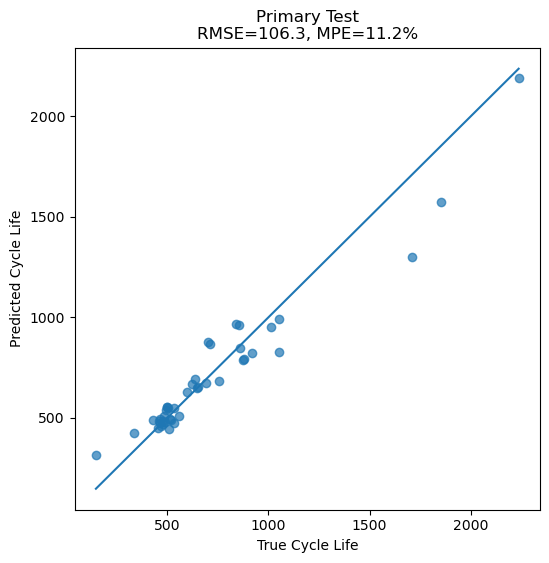

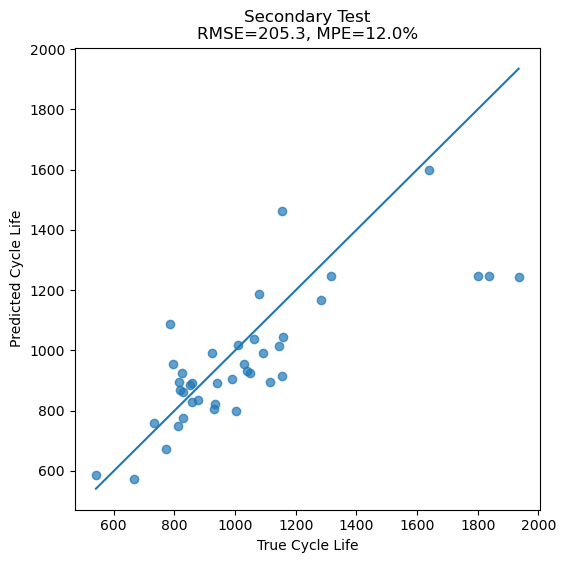

In [12]:
# Final FNO results

model.eval()

# Train predictions

with torch.no_grad():

    train_pred_n = (
        model(X_train_t.to(device))
        .cpu()
        .numpy()
        .ravel()
    )

train_pred_log = train_pred_n * y_std + y_mean

train_pred = (10 ** train_pred_log).ravel()
train_true = (10 ** np.asarray(y_train)).ravel()

train_rmse = np.sqrt(mean_squared_error(train_true, train_pred))
train_mpe = np.mean(np.abs(train_pred - train_true) / train_true) * 100

# Primary test predictions

with torch.no_grad():

    primary_pred_n = (
        model(X_primary_t.to(device))
        .cpu()
        .numpy()
        .ravel()
    )

primary_pred_log = primary_pred_n * y_std + y_mean

primary_pred = (10 ** primary_pred_log).ravel()
primary_true = (10 ** np.asarray(y_primary)).ravel()

primary_rmse = np.sqrt(mean_squared_error(primary_true, primary_pred))
primary_mpe = np.mean(np.abs(primary_pred - primary_true) / primary_true) * 100


# Secondary test predictions

with torch.no_grad():

    secondary_pred_n = (
        model(X_secondary_t.to(device))
        .cpu()
        .numpy()
        .ravel()
    )

secondary_pred_log = secondary_pred_n * y_std + y_mean

secondary_pred = (10 ** secondary_pred_log).ravel()
secondary_true = (10 ** np.asarray(y_secondary)).ravel()

secondary_rmse = np.sqrt(mean_squared_error(secondary_true, secondary_pred))
secondary_mpe = np.mean(np.abs(secondary_pred - secondary_true) / secondary_true) * 100

# Summary table

summary_df = pd.DataFrame({
    "split": ["train", "primary_test", "secondary_test"],
    "rmse_cycles": [train_rmse, primary_rmse, secondary_rmse],
    "mean_percent_error": [train_mpe, primary_mpe, secondary_mpe]
})

display(summary_df)


# Primary test plot

plt.figure(figsize=(6, 6))

plt.scatter(
    primary_true,
    primary_pred,
    alpha=0.7
)

lims = [
    min(primary_true.min(), primary_pred.min()),
    max(primary_true.max(), primary_pred.max())
]

plt.plot(lims, lims)

plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title(f"Primary Test\nRMSE={primary_rmse:.1f}, MPE={primary_mpe:.1f}%")
plt.show()


# Secondary test plot

plt.figure(figsize=(6, 6))

plt.scatter(
    secondary_true,
    secondary_pred,
    alpha=0.7
)

lims = [
    min(secondary_true.min(), secondary_pred.min()),
    max(secondary_true.max(), secondary_pred.max())
]

plt.plot(lims, lims)

plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title(f"Secondary Test\nRMSE={secondary_rmse:.1f}, MPE={secondary_mpe:.1f}%")
plt.show()

In [13]:
# Get ground truth + prediction for every battery
def make_fno_results(battery_ids, true_cycle_life, pred_cycle_life):
    battery_ids = np.asarray(battery_ids).ravel()
    true_cycle_life = np.asarray(true_cycle_life).ravel()
    pred_cycle_life = np.asarray(pred_cycle_life).ravel()

    return pd.DataFrame({
        "battery_id": battery_ids,
        "true_cycle_life": true_cycle_life,
        "pred_cycle_life": pred_cycle_life,
        "abs_percent_error": (np.abs(pred_cycle_life - true_cycle_life) / true_cycle_life * 100)
    })


train_fno_results = make_fno_results(train_ids, train_true, train_pred)
primary_fno_results = make_fno_results(primary_ids, primary_true, primary_pred)
secondary_fno_results = make_fno_results(secondary_ids, secondary_true, secondary_pred)

display(HTML("<h3>Train Set FNO Results</h3>"))
display(train_fno_results)

display(HTML("<h3>Primary Test Set FNO Results</h3>"))
display(primary_fno_results)

display(HTML("<h3>Secondary Test Set FNO Results</h3>"))
display(secondary_fno_results)

,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b1c1,2160.000244,2147.065430,0.598834
1,b1c3,1434.000244,1410.050903,1.670107
2,b1c5,1073.999756,1064.300659,0.903082
3,b1c7,869.999817,870.650574,0.074800
4,b1c11,788.000244,782.127686,0.745248
5,b1c15,718.999817,721.358582,0.328062
6,b1c17,856.999878,860.280701,0.382827
7,b1c19,788.000244,784.841309,0.400880
8,b1c21,558.999878,560.011658,0.180998
9,b1c24,1016.999817,1009.469421,0.740452


,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b1c0,1852.000366,1573.096680,15.059592
1,b1c2,2236.999512,2190.841553,2.063387
2,b1c4,1709.000000,1301.475952,23.845760
3,b1c6,635.999817,691.298218,8.694719
4,b1c9,1053.999756,829.012329,21.346062
5,b1c14,879.999817,795.567810,9.594548
6,b1c16,862.000061,847.069702,1.732060
7,b1c18,691.000000,674.336243,2.411542
8,b1c20,533.999939,547.159424,2.464323
9,b1c23,1014.000000,951.334473,6.180032


,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b3c0,1009.000122,1018.264648,0.918189
1,b3c1,1063.000244,1039.063477,2.251812
2,b3c3,1114.999878,893.961853,19.824039
3,b3c4,1047.999756,926.180847,11.623944
4,b3c5,827.999878,860.681274,3.947029
5,b3c6,666.999939,573.095337,14.078653
6,b3c7,1835.999756,1247.723022,32.041222
7,b3c8,827.999878,776.552490,6.213453
8,b3c9,1039.000244,933.303528,10.172925
9,b3c10,1078.000000,1186.638428,10.077776
